In [4]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

In [5]:


def plot_limits_from_json(json_files, bin_labels, output_file="limits_plot.pdf", y_label="Limit", x_label="Channels", log_y=False):
    """
    Plot expected and observed limits for multiple bins from JSON files in PRL style.

    Parameters:
    - json_files: List of JSON file paths containing limit data.
    - bin_labels: List of bin labels corresponding to the JSON files.
    - output_file: Path to save the generated plot.
    - y_label: Label for the y-axis.
    - x_label: Label for the x-axis.
    """
    if len(json_files) != len(bin_labels):
        raise ValueError("The number of JSON files must match the number of bin labels.")

    # Initialize arrays for plotting
    n_bins = len(json_files)
    x_positions = np.arange(n_bins)
    exp0, exp_plus_1, exp_minus_1, exp_plus_2, exp_minus_2, obs = [], [], [], [], [], []

    # Load data from each JSON file
    for json_file in json_files:
        with open(json_file, "r") as file:
            data = json.load(file)
        key = list(data.keys())[0]  # Assuming the JSON has one key like "120.0"
        exp0.append(data[key]["exp0"])
        exp_plus_1.append(data[key]["exp+1"])
        exp_minus_1.append(data[key]["exp-1"])
        exp_plus_2.append(data[key]["exp+2"])
        exp_minus_2.append(data[key]["exp-2"])
        obs.append(data[key].get("obs", np.nan))  # Set to NaN if not available

    plt.rcParams.update({
        "text.usetex": False,  # Disable LaTeX rendering
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"],
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.figsize": (3.5, 2.5),  # PRL compact size
        "figure.dpi": 300
    })

    # Plotting
    plt.figure(figsize=(6, 4))
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Draw 95% and 68% expected limits as rectangles
    plt.bar(x_positions, np.array(exp_plus_2) - np.array(exp_minus_2), bottom=exp_minus_2,
            width=0.4, color="yellow", label="$\pm 2 \, \mathrm{std. \, dev.}$")
    plt.bar(x_positions, np.array(exp_plus_1) - np.array(exp_minus_1), bottom=exp_minus_1,
            width=0.4, color="green", label="$\pm 1 \, \mathrm{std. \, dev.}$")

    # Plot dashed lines for exp0 as wide as the rectangles
    for x, exp in zip(x_positions, exp0):
        plt.hlines(exp, x - 0.2, x + 0.2, colors='k', linestyles='--', label="Expected" if x == x_positions[0] else None)

    # Plot observed limit if available
    plt.scatter(x_positions, obs, color="black", label="Observed", zorder=15)

    # Add CMS Preliminary text
    plt.text(-0.25, max(np.array(exp_plus_2)) * 1.2 * 1.01, "CMS", fontsize=14, fontweight='bold', va='bottom', ha='left')
    plt.text(-0.1, max(np.array(exp_plus_2)) * 1.2 * 1.01, "Preliminary", fontsize=12, fontstyle='italic', va='bottom', ha='left')

    if log_y:
        plt.yscale("log")
        ymin = min(np.array(exp_minus_2)) * 0.5
        ymax = max(np.array(exp_plus_2)) * 1.2
        if ymin <= 0:
            ymin = 1e-2  # Avoid log(0)
        plt.ylim(ymin, ymax)

    # Add custom bin labels
    plt.xticks(x_positions, bin_labels, rotation=0, fontsize=10)
    plt.xlabel(x_label, fontweight='bold', fontsize=12)
    plt.ylabel(y_label, fontweight='bold', fontsize=12)

    # Set y-axis scale and range
    # plt.yscale("log")
    plt.ylim(min(np.array(exp_minus_2)) * 0.5, max(np.array(exp_plus_2)) * 1.2)

    # Add legend
    plt.legend(fontsize=12, loc="upper right")

    # Save plot
    plt.tight_layout()
    plt.savefig(output_file, format="pdf")
    print(f"Plot saved as {output_file}")
    plt.show()


Plot saved as limits_plot_VH_Hqq_2024_postEE.pdf


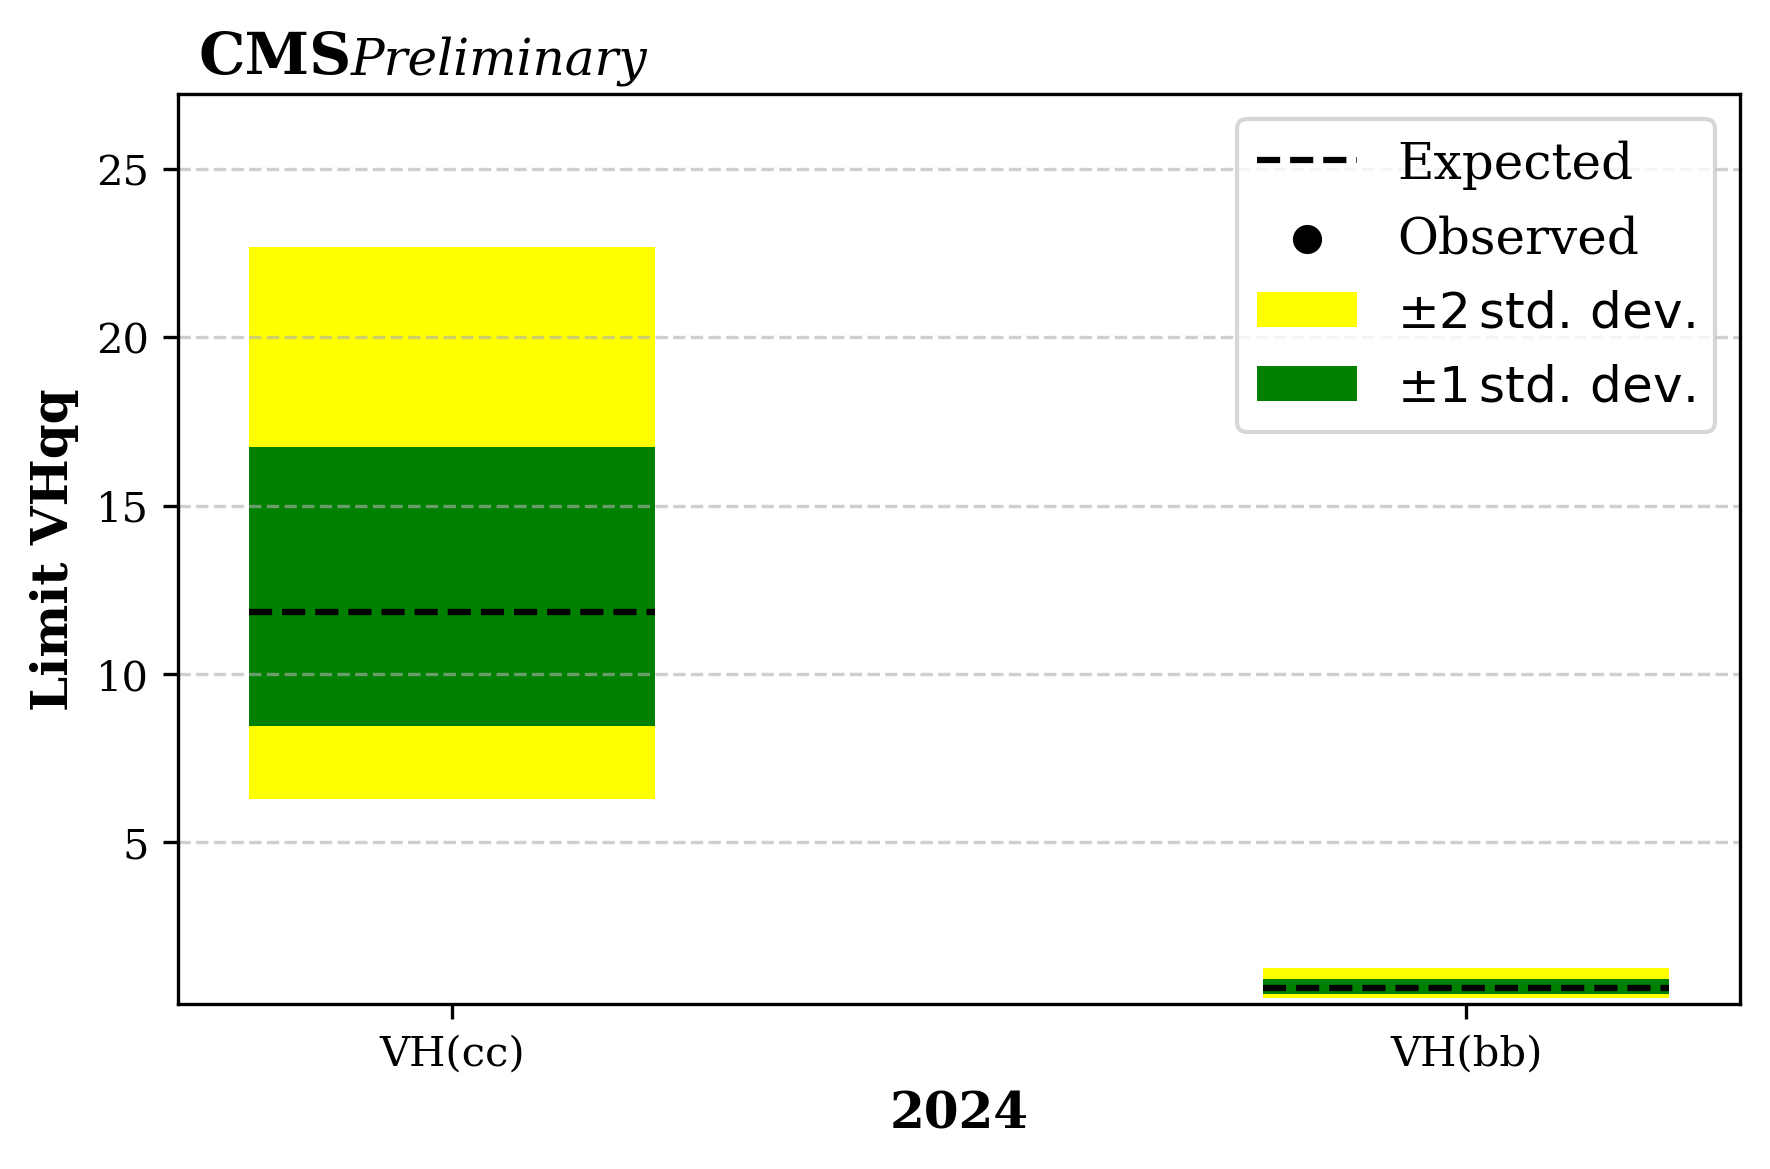

In [6]:
# Example Usage
dir_str = "2024_20260105"
dir_str = '.'
json_files = [f"{dir_str}/2024.limits.Hcc_.json", f"{dir_str}/2024.limits.Hbb_.json"]  # Replace with your JSON file paths
bin_labels = ["VH(cc)", "VH(bb)"]  # Replace with your desired labels
plot_limits_from_json(json_files, bin_labels, y_label="Limit VHqq", x_label="2024", output_file="limits_plot_VH_Hqq_2024_postEE.pdf")

Plot saved as limits_plot_VH_Hqq_1L_2022_postEE.pdf


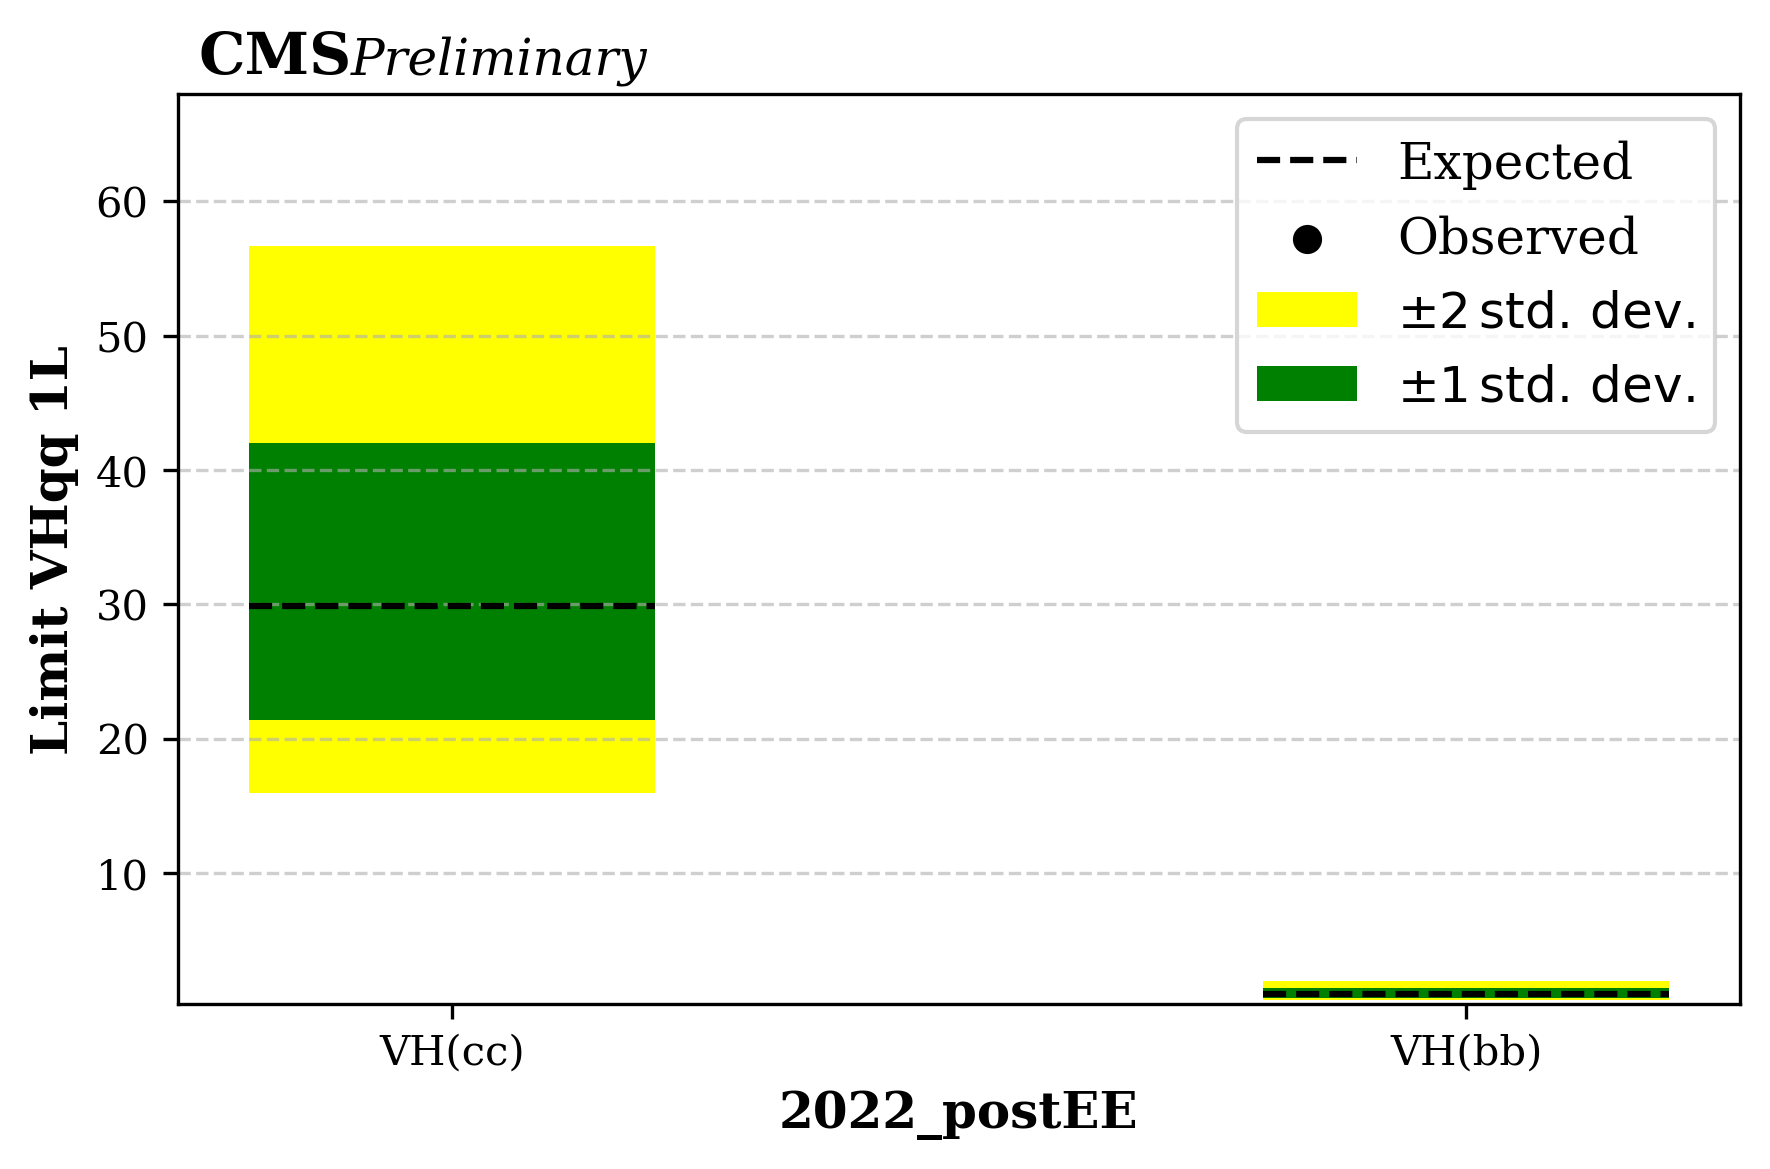

In [6]:
# Example Usage
dir_str = "2022_postEE_20251117"
json_files = [f"{dir_str}/limits.Hcc_1L_default.json", f"{dir_str}/limits.Hbb_1L_default.json"]  # Replace with your JSON file paths
bin_labels = ["VH(cc)", "VH(bb)"]  # Replace with your desired labels
plot_limits_from_json(json_files, bin_labels, y_label="Limit VHqq 1L", x_label="2022_postEE", output_file="limits_plot_VH_Hqq_1L_2022_postEE.pdf")